In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

In [2]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [5]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [6]:
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 1.0


In [7]:
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 1.0


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



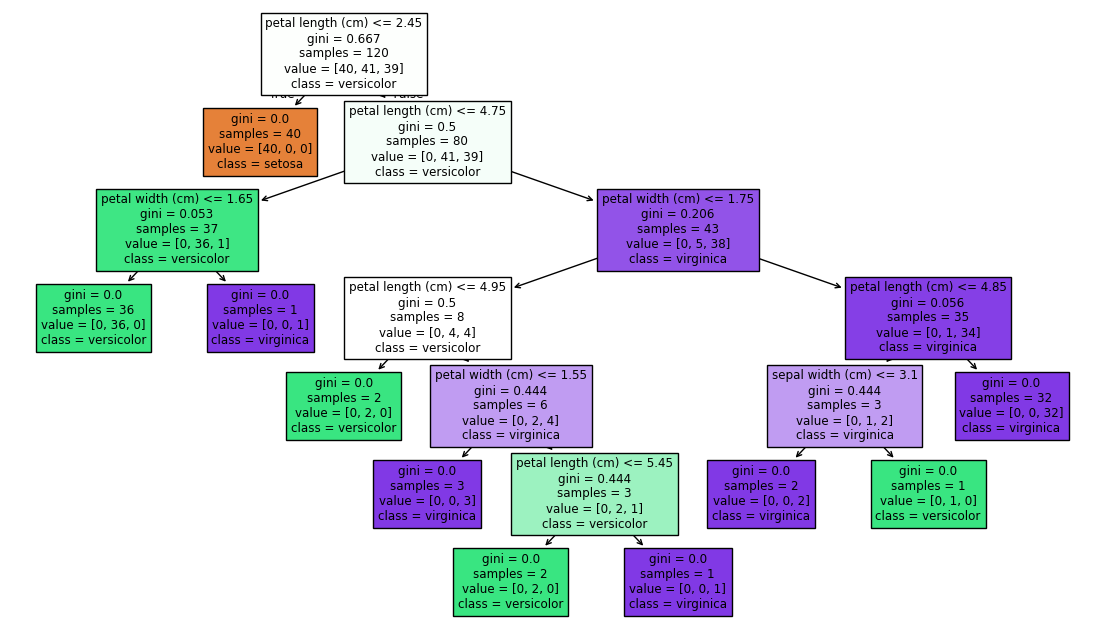

In [9]:
plt.figure(figsize=(14,8))

plot_tree(
    dt,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.show()

In [11]:
dt_small = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_small.fit(X_train, y_train)

pred_small = dt_small.predict(X_test)

print("Pruned Tree Accuracy:",
      accuracy_score(y_test, pred_small))

Pruned Tree Accuracy: 1.0


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [13]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


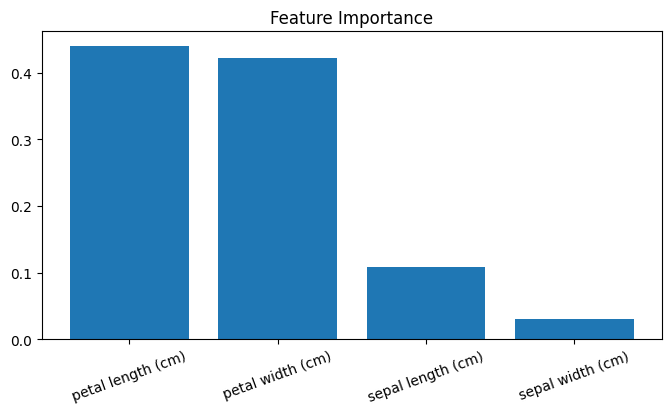

In [15]:
plt.figure(figsize=(8,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xticks(rotation=20)

plt.show()